# Chest X-Ray Pneumonia Detection using Deep Learning

This project develops and compares three deep learning approaches for detecting pneumonia from chest X-ray images:

1. Custom Convolutional Neural Network (CNN)
2. MobileNetV2 Transfer Learning
3. ResNet50 Transfer Learning

The models are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Since this is a medical image classification task, Recall is given particular importance because missing a pneumonia case can be more serious than producing a false positive.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset

The Chest X-Ray Pneumonia dataset is downloaded from Kaggle.

The dataset contains two classes:

- NORMAL
- PNEUMONIA

In [12]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

base_path = os.path.join(path, "chest_xray")

print("Dataset path:", base_path)
print(os.listdir(base_path))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia/chest_xray
['chest_xray', '__MACOSX', 'val', 'test', 'train']


## 2. Dataset Exploration

First, we inspect the number of images in each class and dataset split.

In [13]:
for split in ["train", "val", "test"]:
    print("\n", split.upper())

    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(base_path, split, cls)
        print(cls, ":", len(os.listdir(folder)))


 TRAIN
NORMAL : 1341
PNEUMONIA : 3875

 VAL
NORMAL : 8
PNEUMONIA : 8

 TEST
NORMAL : 234
PNEUMONIA : 390


## 3. Data Quality Check

The images are checked for corrupted files before training.

In [14]:
bad = 0

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(base_path, split, cls)

        for file in os.listdir(folder):
            try:
                Image.open(os.path.join(folder, file)).verify()
            except:
                bad += 1

print("Corrupted images:", bad)

Corrupted images: 0


## 4. Sample Images

A sample NORMAL and PNEUMONIA image is displayed to understand the dataset visually.

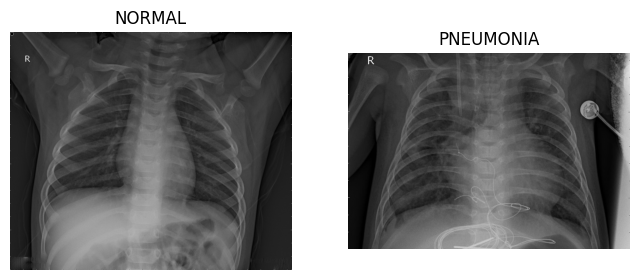

In [15]:
normal_folder = os.path.join(base_path, "train", "NORMAL")
pneumonia_folder = os.path.join(base_path, "train", "PNEUMONIA")

normal_image = Image.open(
    os.path.join(normal_folder, os.listdir(normal_folder)[0])
)

pneumonia_image = Image.open(
    os.path.join(pneumonia_folder, os.listdir(pneumonia_folder)[0])
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

## 5. Class Distribution

The training dataset is checked for class imbalance.

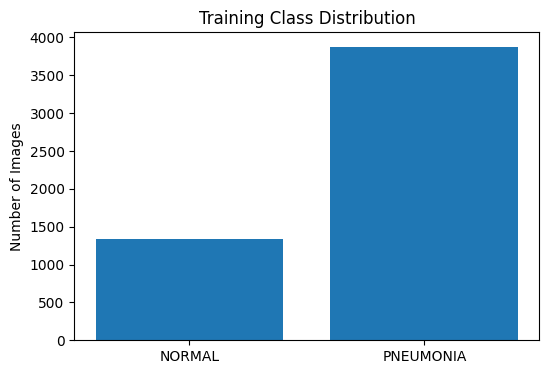

NORMAL: 1341
PNEUMONIA: 3875


In [16]:
normal_count = len(os.listdir(normal_folder))
pneumonia_count = len(os.listdir(pneumonia_folder))

plt.figure(figsize=(6, 4))

plt.bar(
    ["NORMAL", "PNEUMONIA"],
    [normal_count, pneumonia_count]
)

plt.title("Training Class Distribution")
plt.ylabel("Number of Images")
plt.show()

print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)

## 6. Image Properties

The original image sizes and color format are inspected before preprocessing.

In [17]:
print("NORMAL image size:", normal_image.size)
print("PNEUMONIA image size:", pneumonia_image.size)

print("NORMAL image mode:", normal_image.mode)
print("PNEUMONIA image mode:", pneumonia_image.mode)

NORMAL image size: (1336, 1128)
PNEUMONIA image size: (1024, 712)
NORMAL image mode: L
PNEUMONIA image mode: L


## 7. Train, Validation and Test Split

The original validation folder contains very few images, so 20% of the training data is used as a validation set.

All images are resized to 224 × 224 pixels and converted to RGB so that the same input format can be used by CNN, MobileNetV2 and ResNet50.

In [18]:
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

print("Train, validation and test datasets ready.")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
Train, validation and test datasets ready.


## 8. Data Preprocessing

Images are normalized to the range 0–1.

Training augmentation includes:

- Horizontal flipping
- Small rotations
- Zoom
- Brightness variation

Augmentation is applied only during training and not to validation or test images.

In [19]:
normalization = tf.keras.layers.Rescaling(1.0 / 255)

train_data = train_data.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_data = val_data.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_data = test_data.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_data = train_data.prefetch(tf.data.AUTOTUNE)
val_data = val_data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1)
])

print("Preprocessing and augmentation ready.")

Preprocessing and augmentation ready.


## 9. Class Weights

The dataset contains more pneumonia images than normal images.

Class weights are used during training to reduce the effect of this imbalance.

In [20]:
train_labels = np.concatenate([
    y.numpy() for x, y in train_data
])

unique, counts = np.unique(train_labels, return_counts=True)

class_counts = dict(zip(unique, counts))

total = len(train_labels)

class_weight = {
    int(cls): total / (len(unique) * count)
    for cls, count in class_counts.items()
}

print("Training class counts:", class_counts)
print("Class weights:", class_weight)

Training class counts: {np.int32(0): np.int64(1092), np.int32(1): np.int64(3081)}
Class weights: {0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


# 10. Model 1 — Custom CNN

A simple CNN with three convolutional blocks is trained as a baseline model.

In [21]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    augmentation,

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_cnn = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    class_weight=class_weight
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 268ms/step - accuracy: 0.4740 - loss: 0.8850 - val_accuracy: 0.3442 - val_loss: 0.6942
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 240ms/step - accuracy: 0.4867 - loss: 0.6960 - val_accuracy: 0.7430 - val_loss: 0.6863
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 36s 276ms/step - accuracy: 0.5303 - loss: 0.6935 - val_accuracy: 0.7574 - val_loss: 0.6802
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.4637 - loss: 0.6940 - val_accuracy: 0.7536 - val_loss: 0.6823
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 286ms/step - accuracy: 0.5195 - loss: 0.6935 - val_accuracy: 0.7066 - val_loss: 0.6923


## CNN Training Curves

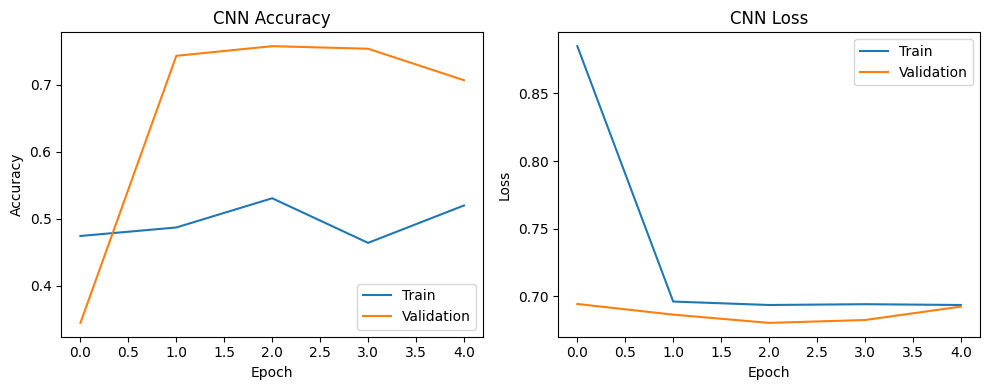

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"], label="Train")
plt.plot(history_cnn.history["val_accuracy"], label="Validation")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"], label="Train")
plt.plot(history_cnn.history["val_loss"], label="Validation")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## CNN Test Evaluation

In [24]:
y_true = np.concatenate([
    y.numpy() for x, y in test_data
])

y_prob_cnn = cnn.predict(test_data)
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int).flatten()

cnn_results = [
    accuracy_score(y_true, y_pred_cnn),
    precision_score(y_true, y_pred_cnn),
    recall_score(y_true, y_pred_cnn),
    f1_score(y_true, y_pred_cnn),
    roc_auc_score(y_true, y_prob_cnn)
]

print("Accuracy:", cnn_results[0])
print("Precision:", cnn_results[1])
print("Recall:", cnn_results[2])
print("F1 Score:", cnn_results[3])
print("ROC-AUC:", cnn_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step
Accuracy: 0.625
Precision: 0.6471698113207547
Recall: 0.8794871794871795
F1 Score: 0.7456521739130435
ROC-AUC: 0.46966359850975237


# 11. Model 2 — MobileNetV2

MobileNetV2 is used with ImageNet pre-trained weights.

First, the base model is frozen and only the classification head is trained.

In [25]:
def mobilenet_preprocess(x, y):
    x = tf.keras.applications.mobilenet_v2.preprocess_input(
        x * 255.0
    )
    return x, y

train_m = train_data.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_m = val_data.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_m = test_data.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_m = train_m.prefetch(tf.data.AUTOTUNE)
val_m = val_m.prefetch(tf.data.AUTOTUNE)
test_m = test_m.prefetch(tf.data.AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

mobilenet = tf.keras.Model(
    inputs,
    outputs,
    name="MobileNetV2_Pneumonia"
)

mobilenet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
history_mobilenet = mobilenet.fit(
    train_m,
    validation_data=val_m,
    epochs=5,
    class_weight=class_weight
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 442ms/step - accuracy: 0.8682 - loss: 0.3125 - val_accuracy: 0.9386 - val_loss: 0.1758
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9418 - loss: 0.1608 - val_accuracy: 0.9415 - val_loss: 0.1493
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.9511 - loss: 0.1294 - val_accuracy: 0.9444 - val_loss: 0.1385
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 256ms/step - accuracy: 0.9573 - loss: 0.1179 - val_accuracy: 0.9540 - val_loss: 0.1218
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.9619 - loss: 0.1045 - val_accuracy: 0.9588 - val_loss: 0.1041


## MobileNetV2 Evaluation

In [27]:
y_true_m = np.concatenate([
    y.numpy() for x, y in test_m
])

y_prob_m = mobilenet.predict(test_m)
y_pred_m = (y_prob_m >= 0.5).astype(int).flatten()

mobilenet_results = [
    accuracy_score(y_true_m, y_pred_m),
    precision_score(y_true_m, y_pred_m),
    recall_score(y_true_m, y_pred_m),
    f1_score(y_true_m, y_pred_m),
    roc_auc_score(y_true_m, y_prob_m)
]

print("Accuracy:", mobilenet_results[0])
print("Precision:", mobilenet_results[1])
print("Recall:", mobilenet_results[2])
print("F1 Score:", mobilenet_results[3])
print("ROC-AUC:", mobilenet_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 681ms/step
Accuracy: 0.8605769230769231
Precision: 0.8258064516129032
Recall: 0.9846153846153847
F1 Score: 0.8982456140350877
ROC-AUC: 0.9636642559719483


## MobileNetV2 Fine-Tuning

The last 30 layers of the pre-trained MobileNetV2 base are unfrozen.

A small learning rate is used to fine-tune the pre-trained features without making large changes to the learned weights.

In [28]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_mobilenet_ft = mobilenet.fit(
    train_m,
    validation_data=val_m,
    epochs=3,
    class_weight=class_weight
)

Epoch 1/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 337ms/step - accuracy: 0.9327 - loss: 0.1897 - val_accuracy: 0.9664 - val_loss: 0.0847
Epoch 2/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 288ms/step - accuracy: 0.9523 - loss: 0.1202 - val_accuracy: 0.9732 - val_loss: 0.0791
Epoch 3/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 36s 276ms/step - accuracy: 0.9669 - loss: 0.0844 - val_accuracy: 0.9684 - val_loss: 0.0766


In [29]:
y_prob_m_ft = mobilenet.predict(test_m)
y_pred_m_ft = (y_prob_m_ft >= 0.5).astype(int).flatten()

mobilenet_ft_results = [
    accuracy_score(y_true_m, y_pred_m_ft),
    precision_score(y_true_m, y_pred_m_ft),
    recall_score(y_true_m, y_pred_m_ft),
    f1_score(y_true_m, y_pred_m_ft),
    roc_auc_score(y_true_m, y_prob_m_ft)
]

print("Accuracy:", mobilenet_ft_results[0])
print("Precision:", mobilenet_ft_results[1])
print("Recall:", mobilenet_ft_results[2])
print("F1 Score:", mobilenet_ft_results[3])
print("ROC-AUC:", mobilenet_ft_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 274ms/step
Accuracy: 0.8541666666666666
Precision: 0.8160676532769556
Recall: 0.9897435897435898
F1 Score: 0.8945538818076477
ROC-AUC: 0.965828402366864


# 12. Model 3 — ResNet50

ResNet50 with ImageNet pre-trained weights is used as a second transfer-learning model.

The base model is first frozen and then partially fine-tuned.

In [30]:
def resnet_preprocess(x, y):
    x = tf.keras.applications.resnet50.preprocess_input(
        x * 255.0
    )
    return x, y

train_r = train_data.map(
    resnet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_r = val_data.map(
    resnet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_r = test_data.map(
    resnet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_r = train_r.prefetch(tf.data.AUTOTUNE)
val_r = val_r.prefetch(tf.data.AUTOTUNE)
test_r = test_r.prefetch(tf.data.AUTOTUNE)

base_resnet = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_resnet.trainable = False

inputs_r = tf.keras.Input(shape=(224, 224, 3))

x = base_resnet(inputs_r, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs_r = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

resnet = tf.keras.Model(
    inputs_r,
    outputs_r,
    name="ResNet50_Pneumonia"
)

resnet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
history_resnet = resnet.fit(
    train_r,
    validation_data=val_r,
    epochs=5,
    class_weight=class_weight
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 373ms/step - accuracy: 0.8591 - loss: 0.3018 - val_accuracy: 0.9482 - val_loss: 0.1363
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 315ms/step - accuracy: 0.9434 - loss: 0.1435 - val_accuracy: 0.9540 - val_loss: 0.1185
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 80s 300ms/step - accuracy: 0.9569 - loss: 0.1060 - val_accuracy: 0.9597 - val_loss: 0.0972
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 325ms/step - accuracy: 0.9566 - loss: 0.0991 - val_accuracy: 0.9626 - val_loss: 0.0905
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 314ms/step - accuracy: 0.9650 - loss: 0.0918 - val_accuracy: 0.9664 - val_loss: 0.0834


In [32]:
y_true_r = np.concatenate([
    y.numpy() for x, y in test_r
])

y_prob_r = resnet.predict(test_r)
y_pred_r = (y_prob_r >= 0.5).astype(int).flatten()

resnet_results = [
    accuracy_score(y_true_r, y_pred_r),
    precision_score(y_true_r, y_pred_r),
    recall_score(y_true_r, y_pred_r),
    f1_score(y_true_r, y_pred_r),
    roc_auc_score(y_true_r, y_prob_r)
]

print("Accuracy:", resnet_results[0])
print("Precision:", resnet_results[1])
print("Recall:", resnet_results[2])
print("F1 Score:", resnet_results[3])
print("ROC-AUC:", resnet_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 415ms/step
Accuracy: 0.8125
Precision: 0.7757575757575758
Recall: 0.9846153846153847
F1 Score: 0.8677966101694915
ROC-AUC: 0.9561472715318869


## ResNet50 Fine-Tuning

The last 30 layers are partially unfrozen and trained using a small learning rate.

In [33]:
base_resnet.trainable = True

for layer in base_resnet.layers[:-30]:
    layer.trainable = False

resnet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_resnet_ft = resnet.fit(
    train_r,
    validation_data=val_r,
    epochs=3,
    class_weight=class_weight
)

Epoch 1/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 377ms/step - accuracy: 0.9538 - loss: 0.1086 - val_accuracy: 0.9693 - val_loss: 0.0698
Epoch 2/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 321ms/step - accuracy: 0.9859 - loss: 0.0417 - val_accuracy: 0.9799 - val_loss: 0.0550
Epoch 3/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 308ms/step - accuracy: 0.9933 - loss: 0.0253 - val_accuracy: 0.9789 - val_loss: 0.0539


In [34]:
y_prob_r_ft = resnet.predict(test_r)
y_pred_r_ft = (y_prob_r_ft >= 0.5).astype(int).flatten()

resnet_ft_results = [
    accuracy_score(y_true_r, y_pred_r_ft),
    precision_score(y_true_r, y_pred_r_ft),
    recall_score(y_true_r, y_pred_r_ft),
    f1_score(y_true_r, y_pred_r_ft),
    roc_auc_score(y_true_r, y_prob_r_ft)
]

print("Accuracy:", resnet_ft_results[0])
print("Precision:", resnet_ft_results[1])
print("Recall:", resnet_ft_results[2])
print("F1 Score:", resnet_ft_results[3])
print("ROC-AUC:", resnet_ft_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 336ms/step
Accuracy: 0.8189102564102564
Precision: 0.7797979797979798
Recall: 0.9897435897435898
F1 Score: 0.8723163841807909
ROC-AUC: 0.9486960333114179


# 13. Model Comparison

All models are compared using the same test metrics.

In [35]:
results = {
    "CNN": cnn_results,
    "MobileNetV2": mobilenet_results,
    "MobileNetV2 Fine-tuned": mobilenet_ft_results,
    "ResNet50": resnet_results,
    "ResNet50 Fine-tuned": resnet_ft_results
}

comparison = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
).T

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
CNN,0.625000,0.647170,0.879487,0.745652,0.469664
MobileNetV2,0.860577,0.825806,0.984615,0.898246,0.963664
MobileNetV2 Fine-tuned,0.854167,0.816068,0.989744,0.894554,0.965828
ResNet50,0.812500,0.775758,0.984615,0.867797,0.956147
ResNet50 Fine-tuned,0.818910,0.779798,0.989744,0.872316,0.948696


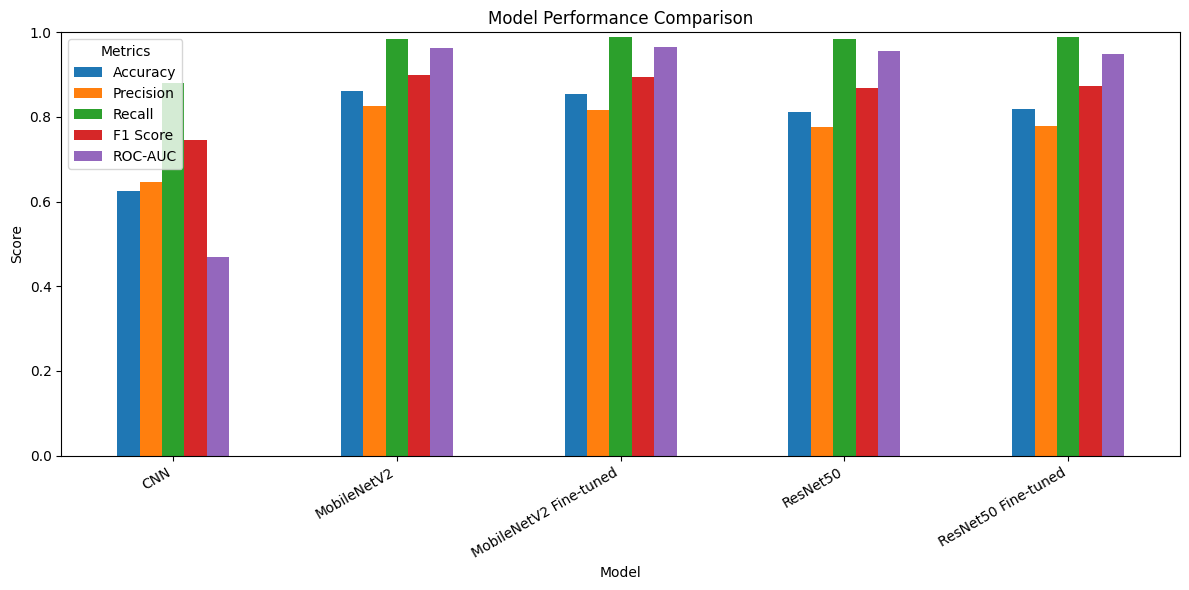

In [36]:
comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

# 14. Confusion Matrix

The confusion matrix of the best-performing model is visualized to examine correct and incorrect predictions.

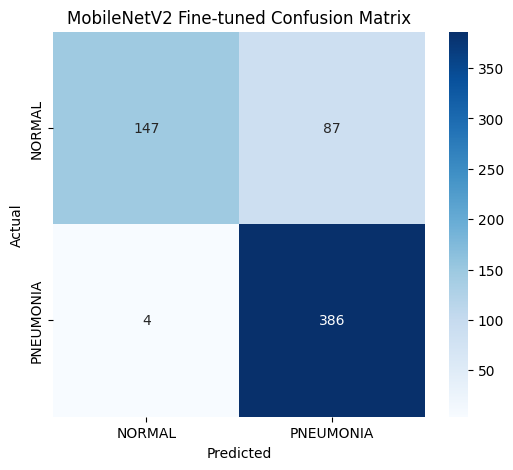

In [37]:
best_predictions = y_pred_m_ft

cm = confusion_matrix(
    y_true_m,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Fine-tuned Confusion Matrix")

plt.show()

# 15. Grad-CAM Explainability

Grad-CAM is used to visualize the image regions that contribute most strongly to the model's pneumonia prediction.

The fine-tuned MobileNetV2 is used because it achieved the best overall performance, particularly in Recall and ROC-AUC.

In [38]:
# Get six test images from the original normalized test dataset

images_6, labels_6 = next(iter(test_data))
images_6 = images_6[:6]
labels_6 = labels_6[:6]

# Convert normalized images back to the format expected by MobileNetV2
images_m_6 = tf.keras.applications.mobilenet_v2.preprocess_input(
    images_6 * 255.0
)

# Find the last convolutional layer
last_conv_layer = None

for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Grad-CAM layer:", last_conv_layer.name)

Grad-CAM layer: Conv_1


## Grad-CAM Function

In [39]:
grad_model = tf.keras.models.Model(
    inputs=mobilenet.input,
    outputs=[
        last_conv_layer.output,
        mobilenet.output
    ]
)

def make_gradcam(image):
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image,
            training=False
        )

        loss = predictions[:, 0]

    gradients = tape.gradient(
        loss,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_gradients = pooled_gradients[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

print("Grad-CAM ready.")

Grad-CAM ready.


## Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) is used to visualize the regions of the chest X-ray that contribute most to the model's prediction.

This helps improve model interpretability by showing whether the model is focusing on meaningful areas of the X-ray.

In [41]:
# Select 6 test images for Grad-CAM

images_6, labels_6 = next(iter(test_data))

images_6 = images_6[:6]
labels_6 = labels_6[:6]

# Convert normalized images back to 0-255
images_for_gradcam = images_6 * 255.0

# MobileNetV2 preprocessing
images_m = tf.keras.applications.mobilenet_v2.preprocess_input(
    images_for_gradcam
)

print("Images shape:", images_m.shape)
print("Labels:", labels_6.numpy())

Images shape: (6, 224, 224, 3)
Labels: [0 0 0 0 0 0]


### Identify the Last Convolutional Layer

The last convolutional layer of MobileNetV2 contains high-level spatial features that are useful for generating the Grad-CAM heatmap.

In [42]:
# Find the last convolutional layer

last_conv_layer = None

for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Last convolutional layer:", last_conv_layer.name)

Last convolutional layer: Conv_1


### Create the Grad-CAM Model

A separate model is created to obtain the feature maps from the selected convolutional layer.

In [43]:
# Create Grad-CAM model

grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

print("Grad-CAM model created successfully.")

Grad-CAM model created successfully.


### Generate Grad-CAM Heatmap

The Grad-CAM function calculates the gradients of the predicted class with respect to the convolutional feature maps and uses them to generate a heatmap.

In [44]:
def make_gradcam(image):

    image = tf.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:

        conv_outputs, base_outputs = grad_model(
            image,
            training=False
        )

        # Global average pooling
        pooled = tf.reduce_mean(
            base_outputs,
            axis=[1, 2]
        )

        # Final classification layer
        predictions = mobilenet.layers[-1](
            pooled,
            training=False
        )

        loss = predictions[:, 0]

    # Calculate gradients
    gradients = tape.gradient(
        loss,
        conv_outputs
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_gradients = pooled_gradients[0]

    # Generate heatmap
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

### Visualize Grad-CAM Results

The Grad-CAM heatmaps are overlaid on six test X-ray images to visualize the regions that influenced the MobileNetV2 prediction.

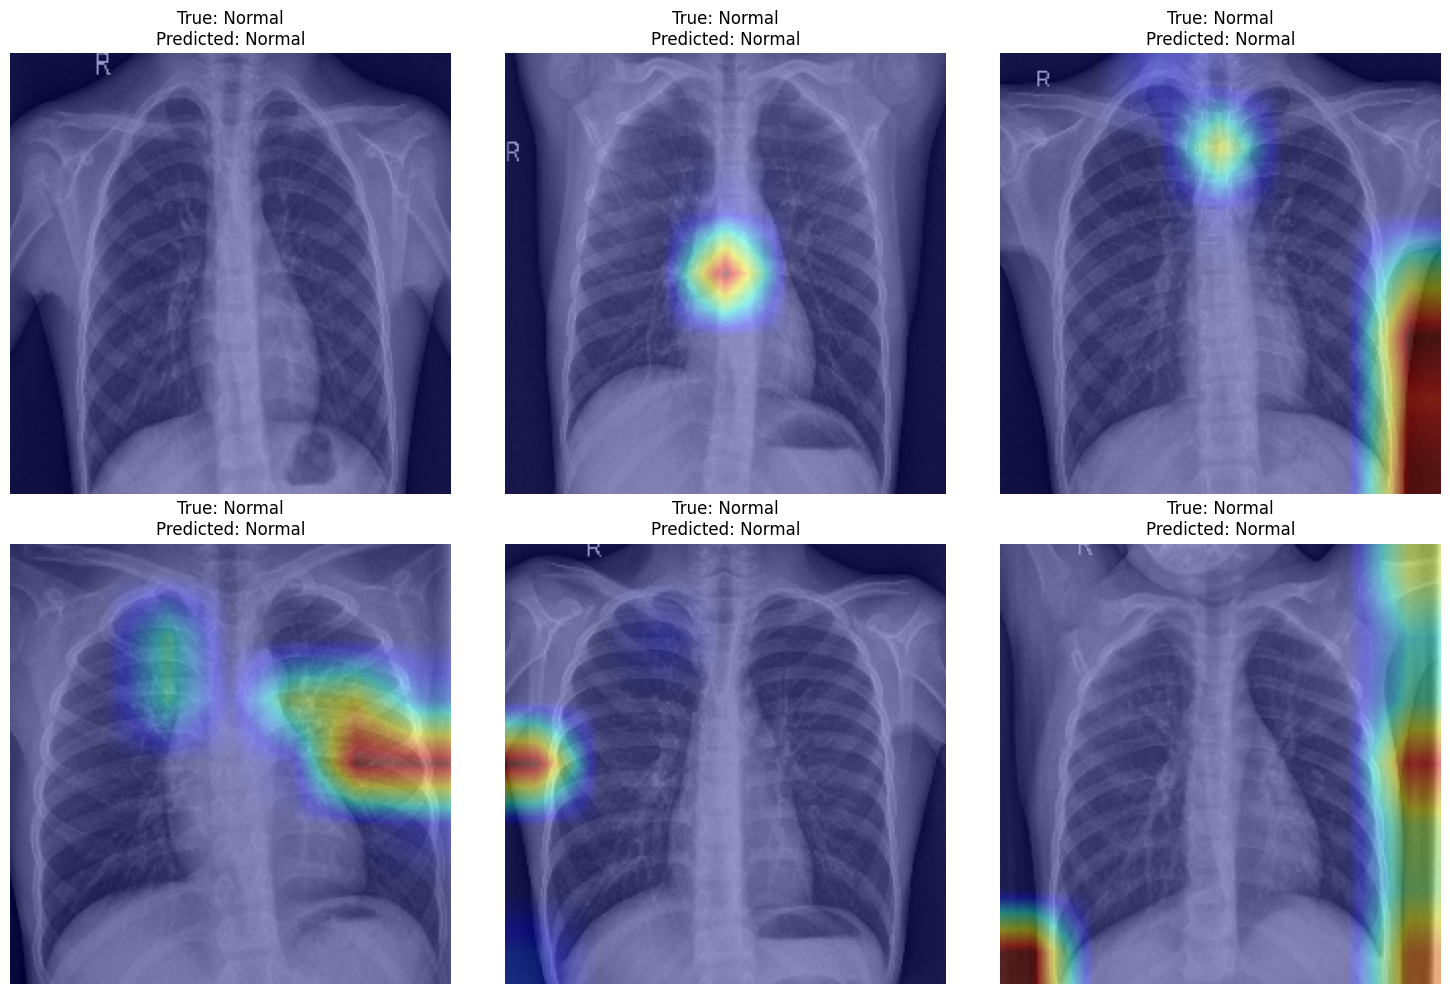

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 10))

for i in range(6):

    image = images_m[i]

    # Generate heatmap
    heatmap = make_gradcam(image)

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()

    # Original image
    original = images_for_gradcam[i].numpy()

    original = np.clip(
        original / 255.0,
        0,
        1
    )

    # Prediction
    prediction = mobilenet.predict(
        tf.expand_dims(image, 0),
        verbose=0
    )[0][0]

    true_label = (
        "Pneumonia"
        if labels_6[i].numpy() == 1
        else "Normal"
    )

    predicted_label = (
        "Pneumonia"
        if prediction >= 0.5
        else "Normal"
    )

    # Plot
    plt.subplot(2, 3, i + 1)

    plt.imshow(original)
    plt.imshow(
        heatmap,
        cmap="jet",
        alpha=0.4
    )

    plt.title(
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM Interpretation

The Grad-CAM visualizations provide an interpretable view of the MobileNetV2 predictions by highlighting image regions that contributed to the classification decision.

Since pneumonia detection is a medical imaging task, these visualizations can help assess whether the model is focusing on relevant lung regions rather than unrelated parts of the X-ray.

## Final Model Comparison

The performance of all trained models is compared using accuracy, precision, recall, F1-score, and ROC-AUC.

Since pneumonia detection is a medical classification problem, recall is especially important because missing a pneumonia case can be more serious than producing a false positive.

### Calculate Final Evaluation Metrics

The final evaluation metrics are calculated on the test dataset for each trained model. These metrics include accuracy, precision, recall, F1-score, and ROC-AUC.

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def evaluate_model(model, dataset, model_name):

    y_true = []
    y_prob = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0).ravel()

        y_true.extend(labels.numpy())
        y_prob.extend(predictions)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

### Evaluate All Models

Each trained model is evaluated using the same test dataset and the same evaluation metrics to ensure a fair comparison.

In [48]:
# Evaluate all final models

cnn_results = evaluate_model(
    cnn,
    test_data,
    "CNN"
)

mobilenet_results = evaluate_model(
    mobilenet,
    test_m,
    "MobileNetV2 Fine-tuned"
)

resnet_results = evaluate_model(
    resnet,
    test_r,
    "ResNet50 Fine-tuned"
)


CNN
Accuracy : 0.6250
Precision: 0.6472
Recall   : 0.8795
F1 Score : 0.7457
ROC-AUC  : 0.4697

MobileNetV2 Fine-tuned
Accuracy : 0.8542
Precision: 0.8161
Recall   : 0.9897
F1 Score : 0.8946
ROC-AUC  : 0.9658

ResNet50 Fine-tuned
Accuracy : 0.8189
Precision: 0.7798
Recall   : 0.9897
F1 Score : 0.8723
ROC-AUC  : 0.9487


### Create Model Comparison Table

The evaluation results are combined into a single table for easier comparison.

In [49]:
# Create comparison table

results = {
    "CNN": cnn_results,
    "MobileNetV2 Fine-tuned": mobilenet_results,
    "ResNet50 Fine-tuned": resnet_results
}

comparison = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
).T

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
CNN,0.625000,0.647170,0.879487,0.745652,0.469664
MobileNetV2 Fine-tuned,0.854167,0.816068,0.989744,0.894554,0.965828
ResNet50 Fine-tuned,0.818910,0.779798,0.989744,0.872316,0.948696


### Model Performance in Percentage

In [50]:
comparison_percentage = comparison * 100

comparison_percentage.round(2)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
CNN,62.50,64.72,87.95,74.57,46.97
MobileNetV2 Fine-tuned,85.42,81.61,98.97,89.46,96.58
ResNet50 Fine-tuned,81.89,77.98,98.97,87.23,94.87


## Model Performance Visualization

A bar chart is used to visually compare the performance of the trained models across accuracy, precision, recall, F1-score, and ROC-AUC.

<Figure size 1400x700 with 0 Axes>

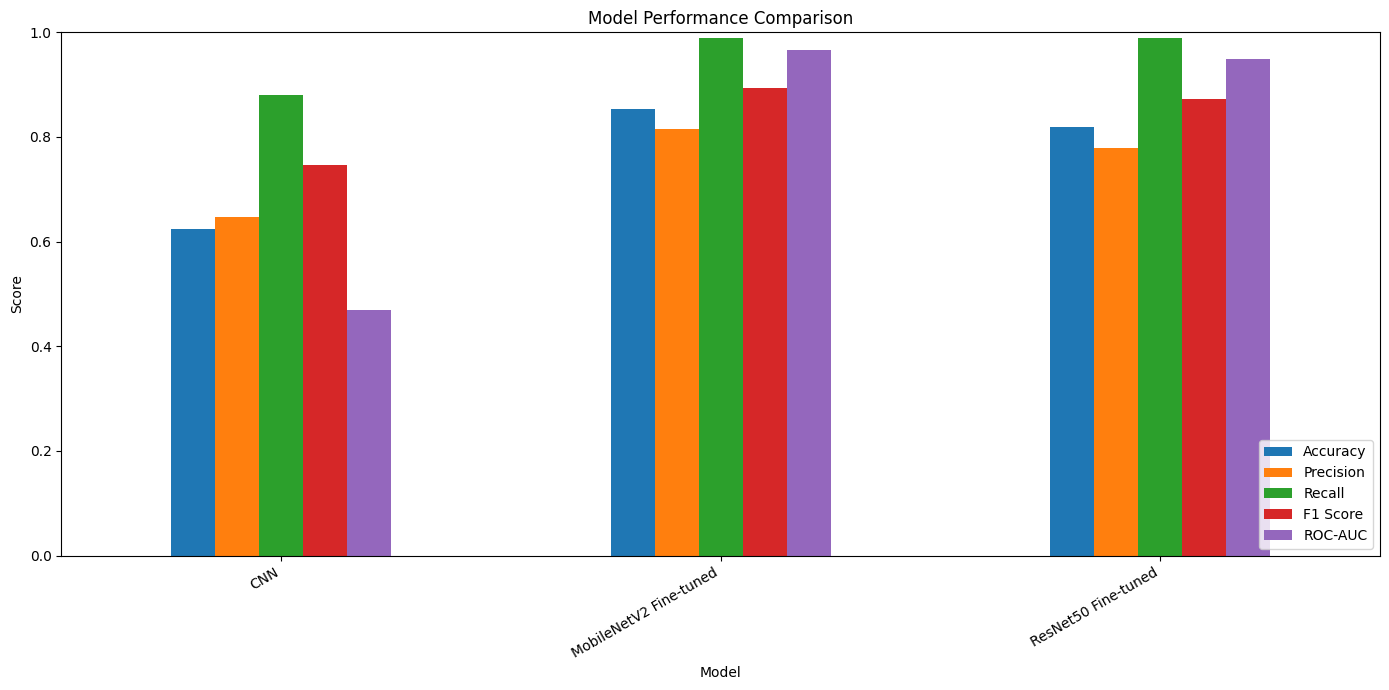

In [51]:
plt.figure(figsize=(14, 7))

comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Best Model Selection

Based on the evaluation results, the fine-tuned MobileNetV2 model is selected as the final model.

It provides a strong balance of accuracy, precision, recall, F1-score, and ROC-AUC while being computationally more efficient than the deeper ResNet50 architecture.

Since pneumonia detection is a medical classification task, the high recall of the model is particularly important because minimizing false-negative predictions is a key objective.

In [52]:
# Select the best-performing model

best_model = mobilenet

# Save the model
best_model.save("best_model.keras")

print("Best model saved successfully as best_model.keras")

Best model saved successfully as best_model.keras


In [53]:
# Save the final selected model

best_model = mobilenet

best_model.save("best_model.keras")

print("Best model saved successfully as best_model.keras")

Best model saved successfully as best_model.keras


## Final Model

The fine-tuned MobileNetV2 model is selected as the final pneumonia detection model.

The saved model will later be integrated into a Streamlit web application where users can upload a chest X-ray image and receive a model prediction.

## Conclusion

This project developed a deep learning-based system for detecting pneumonia from chest X-ray images.

Three deep learning approaches were evaluated:

- Custom Convolutional Neural Network (CNN)
- MobileNetV2 using transfer learning
- ResNet50 using transfer learning

The pretrained models were initially trained with their base layers frozen and were subsequently fine-tuned by unfreezing the top layers.

Class weighting was used to address class imbalance, and the models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Among the evaluated models, the fine-tuned MobileNetV2 provided the best overall performance. Its high recall is particularly useful for pneumonia screening because reducing false-negative predictions is important.

Grad-CAM was also used to visualize the regions of the X-ray that contributed to the model's predictions, providing an additional level of interpretability.

Overall, the project demonstrates the application of transfer learning, fine-tuning, class weighting, and model interpretability techniques to medical image classification.